In [1]:
import pandas as pd
import numpy as np
import random
import sklearn.datasets as datasets
from data_consistency_checker import DataConsistencyChecker

In [2]:
pd.options.display.max_columns = 1000
pd.options.display.max_colwidth = 1000
pd.options.display.max_rows = 1000
pd.options.display.width = 10000

In [3]:
# This notebook provides examples of many of the APIs available. This includes
# some APIs that would not be necessary for most EDA or outlier detection work,
# but are useful in some situations. Many of the more common APIs are not shown
# here, as they are covered in other example notebooks. 

In [4]:
# Load a dataset. In this example, we use the breast cancer dataset included
# with sklearn.

data = datasets.load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Create a DataConsistencyChecker object

dc = DataConsistencyChecker() 

In [6]:
# Get a list of the available tests. We may wish to run just certain tests,
# or to exclude certain tests, when calling check_data_quality(), the main
# API. As well, after running check_data_quality(), we may wish to focus 
# on certain tests, for example, calling display_detailed_results(), 
# specifying some subset of these. 

dc.get_test_list()

['MISSING_VALUES',
 'RARE_VALUES',
 'UNIQUE_VALUES',
 'PREV_VALUES_DT',
 'MATCHED_MISSING',
 'OPPOSITE_MISSING',
 'SAME_VALUES',
 'SAME_OR_CONSTANT',
 'UNIQUE_PAIR',
 'POSITIVE',
 'NEGATIVE',
 'NUMBER_DECIMALS',
 'RARE_DECIMALS',
 'COLUMN_ORDERED_ASC',
 'COLUMN_ORDERED_DESC',
 'COLUMN_TENDS_ASC',
 'COLUMN_TENDS_DESC',
 'SIMILAR_PREVIOUS',
 'UNUSUAL_ORDER_MAGNITUDE',
 'FEW_NEIGHBORS',
 'FEW_WITHIN_RANGE',
 'VERY_SMALL',
 'VERY_LARGE',
 'VERY_SMALL_ABS',
 'MULTIPLE_OF_CONSTANT',
 'ROUNDING',
 'NON_ZERO',
 'LESS_THAN_ONE',
 'GREATER_THAN_ONE',
 'INVALID_NUMBERS',
 'LARGER_DIFF_RANGE',
 'LARGER_SAME_RANGE',
 'MUCH_LARGER',
 'SIMILAR_WRT_RATIO',
 'SIMILAR_WRT_DIFF',
 'SIMILAR_TO_INVERSE',
 'SIMILAR_TO_NEGATIVE',
 'CONSTANT_SUM',
 'CONSTANT_DIFF',
 'CONSTANT_PRODUCT',
 'CONSTANT_RATIO',
 'EVEN_MULTIPLE',
 'RARE_COMBINATION',
 'CORRELATED_NUMERIC',
 'MATCHED_ZERO',
 'OPPOSITE_ZERO',
 'RUNNING_SUM',
 'A_ROUNDED_B',
 'MATCHED_ZERO_MISSING',
 'SIMILAR_TO_DIFF',
 'SIMILAR_TO_PRODUCT',
 'SIMILAR_T

In [7]:
# Calling get_test_list() provides a list of the test ids, which are used as
# parameters for some other APIs. get_test_descriptions() can provide a 
# description of what each test does. This is returned in a dictionary.
# This may be used for programmatic processing of the tests, but is not 
# intended for display. For that, use print_test_descriptions(), described 
# below.

descriptions_dict = dc.get_test_descriptions()

In [8]:
# print_test_descriptions() provides a more readable output of the available tests. 

dc.print_test_descriptions()

MISSING_VALUES:                Check if all values in a column are consistently present / consistently missing.
RARE_VALUES:                   Check if there are any rare values in a column.
UNIQUE_VALUES:                 Check if there are consistently unique values with a column.
PREV_VALUES_DT:                Check if the values in a column can be predicted from previous values in that column using
                                 a simple decision tree.
MATCHED_MISSING:               Check if two columns have missing values consistently in the same rows.
OPPOSITE_MISSING:              Check if two columns both frequently have null values, but consistently not in the same
                                 rows.
SAME_VALUES:                   Check if two columns consistently have the same values.
SAME_OR_CONSTANT:              Check one column consistently has either the same value as another column, or a small
                                 number of other values.
UNIQUE_PAIR:    

In [9]:
# To identify patterns and exceptions in the dataset, we create a 
# DataConsistencyChecker object (this was done above, but is repeated
# here), initialize it with the dataset we wish to check, and call 
# check_data_quality().

dc = DataConsistencyChecker()  
dc.init_data(df)
_ = dc.check_data_quality()

Executing test   0: MISSING_VALUES                
Executing test   1: RARE_VALUES                   
Executing test   2: UNIQUE_VALUES                 
Executing test   3: PREV_VALUES_DT                


Executing test   4: MATCHED_MISSING               
Executing test   5: OPPOSITE_MISSING              
Executing test   6: SAME_VALUES                   
Executing test   7: SAME_OR_CONSTANT              


Executing test   8: UNIQUE_PAIR                   
Executing test   9: POSITIVE                      
Executing test  10: NEGATIVE                      
Executing test  11: NUMBER_DECIMALS               
Executing test  12: RARE_DECIMALS                 
Executing test  13: COLUMN_ORDERED_ASC            
Executing test  14: COLUMN_ORDERED_DESC           
Executing test  15: COLUMN_TENDS_ASC              
Executing test  16: COLUMN_TENDS_DESC             
Executing test  17: SIMILAR_PREVIOUS              


Executing test  18: UNUSUAL_ORDER_MAGNITUDE       
Executing test  19: FEW_NEIGHBORS                 
Executing test  20: FEW_WITHIN_RANGE              


Executing test  21: VERY_SMALL                    
Executing test  22: VERY_LARGE                    
Executing test  23: VERY_SMALL_ABS                
Executing test  24: MULTIPLE_OF_CONSTANT          


...

Executing test  54: MEAN_OF_COLUMNS               
  Due to the potential number of combinations, limiting test to subsets of size 5.


Executing test  55: MIN_OF_COLUMNS                
Executing test  56: MAX_OF_COLUMNS                
Executing test  57: MATCHED_SET_POS_NEG           
Executing test  58: MATCHED_SET_ZERO_NON_ZERO     
Executing test  59: DECISION_TREE_REGRESSOR       


Executing test  60: LINEAR_REGRESSION             


Executing test  61: PREDICT_NULL_DT               
Executing test  62: EARLY_DATES                   
Executing test  63: LATE_DATES                    
Executing test  64: UNUSUAL_DAY_OF_WEEK           
Executing test  65: UNUSUAL_DAY_OF_MONTH          
Executing test  66: UNUSUAL_MONTH                 
Executing test  67: UNUSUAL_HOUR                  
Executing test  68: UNUSUAL_MINUTES               
Executing test  69: CONSTANT_DOM                  
Executing test  70: CONSTANT_LAST_DOM             
Executing test  71: CONSTANT_GAP                  
Executing test  72: LARGE_GAP                     
Executing test  73: SMALL_GAP                     
Executing test  74: LATER                         
Executing test  75: SAME_DATE                     
Executing test  76: SAME_MONTH                    
Executing test  77: CORRELATED_DATES              
Executing test  78: LARGE_GIVEN_DATE              
Executing test  79: SMALL_GIVEN_DATE              
Executing test  80: BLANK_VALUE


Data consistency check complete.
Analysed 569 rows, 30 columns
Executed 158 tests.

Patterns without Exceptions:
Found 157 patterns without exceptions
15 tests (9.49% of tests) identified at least one pattern without exceptions each. 
By default some patterns are not listed in calls to display_detailed_results().

Patterns with Exceptions:
Found 46 patterns with exceptions
10 tests (6.33% of tests) flagged at least one exception each.
Flagged 29 row(s) with at least one exception.
Flagged 29 column(s) with at least one exception.


In [10]:
# The tests performed on each column are based partially on which type of 
# data the tool identified in the columns. All columns are classified as
# either string, numeric, binary, or date/time. To see how each column
# was classified, call display_columns_types_list().

dc.display_columns_types_list()

**String&nbsp;Columns**:

None

**Numeric&nbsp;Columns**:

'mean&nbsp;radius',&nbsp;'mean&nbsp;texture',&nbsp;'mean&nbsp;perimeter',&nbsp;'mean&nbsp;area',&nbsp;'mean&nbsp;smoothness',&nbsp;'mean&nbsp;compactness',&nbsp;'mean&nbsp;concavity',&nbsp;'mean&nbsp;concave&nbsp;points',&nbsp;'mean&nbsp;symmetry',&nbsp;'mean&nbsp;fractal&nbsp;dimension',&nbsp;'radius&nbsp;error',&nbsp;'texture&nbsp;error',&nbsp;'perimeter&nbsp;error',&nbsp;'area&nbsp;error',&nbsp;'smoothness&nbsp;error',&nbsp;'compactness&nbsp;error',&nbsp;'concavity&nbsp;error',&nbsp;'concave&nbsp;points&nbsp;error',&nbsp;'symmetry&nbsp;error',&nbsp;'fractal&nbsp;dimension&nbsp;error',&nbsp;'worst&nbsp;radius',&nbsp;'worst&nbsp;texture',&nbsp;'worst&nbsp;perimeter',&nbsp;'worst&nbsp;area',&nbsp;'worst&nbsp;smoothness',&nbsp;'worst&nbsp;compactness',&nbsp;'worst&nbsp;concavity',&nbsp;'worst&nbsp;concave&nbsp;points',&nbsp;'worst&nbsp;symmetry',&nbsp;'worst&nbsp;fractal&nbsp;dimension'

**Binary&nbsp;Columns**:

None

**Date/Time&nbsp;Columns**:

None

In [11]:
# It is also possible to view this with example values of each column. 

dc.display_columns_types_table()

Assigned&nbsp;column&nbsp;types&nbsp;and&nbsp;example&nbsp;rows:

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.186,0.275,0.08902
2,19.69,21.25,130.0,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.00615,0.04006,0.03832,0.02058,0.0225,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.243,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.09744,0.4956,1.156,3.445,27.23,0.00911,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173
4,20.29,14.34,135.1,1297.0,0.1003,0.1328,0.198,0.1043,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.01149,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.2,1575.0,0.1374,0.205,0.4,0.1625,0.2364,0.07678


In [12]:
# Calling display_detailed_results() with default parameters will list
# all patterns and exceptions found, unless there are too many to reasonably
# display. In this case, there are too many to show at once, so we remove
# the patterns without exceptions and display only the patterns with 
# exceptions. This is still a large number, but is manageable to go through.
# We also leave out the plots here, to keep the notebook to a reasonable size.

dc.display_detailed_results(show_patterns=False, plot_results=False)

....................................................................................................


### NUMBER_DECIMALS

### Columns(s): mean concavity

**Issue&nbsp;ID**:&nbsp;0

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;1&nbsp;(0.1757%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,mean radius,mean perimeter,mean concavity,mean fractal dimension,radius error,perimeter error,compactness error,worst area,worst concave points,mean area,PREDICTION
45,18.650000,123.700000,0.197400,0.060490,0.628900,4.293000,0.039940,1567.000000,0.237800,1076.000000,1085.430325
49,13.490000,86.910000,0.047510,0.057180,0.233800,1.735000,0.013820,698.800000,0.128200,561.000000,559.071719
67,11.310000,71.800000,0.037090,0.056670,0.272700,1.831000,0.009216,466.700000,0.069610,394.100000,392.404610
85,18.460000,121.100000,0.133500,0.060220,0.699700,4.782000,0.016490,1603.000000,0.164200,1075.000000,1079.449979
88,12.360000,79.780000,0.060150,0.064040,0.297800,2.203000,0.024930,574.700000,0.120500,466.100000,469.772448
100,13.610000,88.050000,0.086250,0.058710,0.456500,2.861000,0.014880,906.500000,0.118400,582.700000,572.379632
113,10.510000,68.640000,0.064760,0.077820,0.333600,2.041000,0.037470,374.400000,0.061360,334.200000,328.168416
137,11.430000,73.060000,0.035030,0.058650,0.175900,1.143000,0.015210,462.000000,0.084760,399.800000,392.481105
143,12.900000,83.740000,0.048940,0.062350,0.214300,1.689000,0.015630,643.800000,0.101200,512.200000,512.471348
205,15.120000,98.780000,0.075500,0.059860,0.271100,1.974000,0.019190,989.500000,0.125200,716.600000,720.656699


**Flagged&nbsp;values**:

,mean radius,mean perimeter,mean concavity,mean fractal dimension,radius error,perimeter error,compactness error,worst area,worst concave points,mean area,PREDICTION
212,28.110000,188.500000,0.320100,0.055250,2.873000,21.980000,0.027720,2499.000000,0.159500,2499.000000,2165.691016


In [13]:
# To aid examining the results, get_test_ids_with_results() may be
# called to get a list of tests that found any patterns, with or
# without exceptions. This returns a python list, which allows
# programmatically looping through these. 

dc.get_test_ids_with_results()

['MISSING_VALUES',
 'POSITIVE',
 'NUMBER_DECIMALS',
 'UNUSUAL_ORDER_MAGNITUDE',
 'FEW_NEIGHBORS',
 'VERY_LARGE',
 'NON_ZERO',
 'LESS_THAN_ONE',
 'GREATER_THAN_ONE',
 'LARGER_DIFF_RANGE',
 'LARGER_SAME_RANGE',
 'MUCH_LARGER',
 'SIMILAR_WRT_RATIO',
 'RARE_COMBINATION',
 'CORRELATED_NUMERIC',
 'MATCHED_ZERO',
 'LINEAR_REGRESSION',
 'MISSING_VALUES_PER_ROW',
 'NEGATIVE_VALUES_PER_ROW']

In [14]:
# We may wish to also look at the patterns without exceptions. By default, 
# some patterns found are not displayed in some API results, as they are 
# common and not as interesting. For example, the test NEGATIVE is, but 
# POSITIVE is not, as a column of entirely negative numbers is more 
# interesting than one of entirely POSITIVE numbers. To see which tests
# are displayed as patterns in all APIs, call get_patterns_shortlist().

dc.get_patterns_shortlist()

['UNIQUE_VALUES',
 'PREV_VALUES_DT',
 'MATCHED_MISSING',
 'OPPOSITE_MISSING',
 'SAME_VALUES',
 'SAME_OR_CONSTANT',
 'UNIQUE_PAIR',
 'NEGATIVE',
 'RARE_DECIMALS',
 'COLUMN_ORDERED_ASC',
 'COLUMN_ORDERED_DESC',
 'COLUMN_TENDS_ASC',
 'COLUMN_TENDS_DESC',
 'SIMILAR_PREVIOUS',
 'VERY_SMALL',
 'VERY_LARGE',
 'VERY_SMALL_ABS',
 'MULTIPLE_OF_CONSTANT',
 'ROUNDING',
 'LESS_THAN_ONE',
 'LARGER_SAME_RANGE',
 'SIMILAR_WRT_RATIO',
 'SIMILAR_WRT_DIFF',
 'SIMILAR_TO_INVERSE',
 'SIMILAR_TO_NEGATIVE',
 'CONSTANT_SUM',
 'CONSTANT_DIFF',
 'CONSTANT_PRODUCT',
 'CONSTANT_RATIO',
 'EVEN_MULTIPLE',
 'RARE_COMBINATION',
 'CORRELATED_NUMERIC',
 'MATCHED_ZERO',
 'OPPOSITE_ZERO',
 'RUNNING_SUM',
 'A_ROUNDED_B',
 'MATCHED_ZERO_MISSING',
 'SIMILAR_TO_DIFF',
 'SIMILAR_TO_PRODUCT',
 'SIMILAR_TO_RATIO',
 'SUM_OF_COLUMNS',
 'MEAN_OF_COLUMNS',
 'MIN_OF_COLUMNS',
 'MAX_OF_COLUMNS',
 'MATCHED_SET_POS_NEG',
 'MATCHED_SET_ZERO_NON_ZERO',
 'DECISION_TREE_REGRESSOR',
 'LINEAR_REGRESSION',
 'PREDICT_NULL_DT',
 'EARLY_DATES',


In [15]:
# We next call get_patterns_list() to get a list of the patterns without exceptions found.

dc.get_patterns_list()

Some&nbsp;patterns&nbsp;not&nbsp;shown.&nbsp;Set&nbsp;show_short_list_only&nbsp;to&nbsp;False&nbsp;to&nbsp;see&nbsp;additional&nbsp;patterns.

,Test ID,Column(s),Description of Pattern,Pattern ID
113,LESS_THAN_ONE,mean smoothness,"The column consistently contains values between -1.0, and 1.0 (inclusive)",113
114,LESS_THAN_ONE,mean compactness,"The column consistently contains values between -1.0, and 1.0 (inclusive)",114
115,LESS_THAN_ONE,mean concavity,"The column consistently contains values between -1.0, and 1.0 (inclusive)",115
116,LESS_THAN_ONE,mean concave points,"The column consistently contains values between -1.0, and 1.0 (inclusive)",116
117,LESS_THAN_ONE,mean symmetry,"The column consistently contains values between -1.0, and 1.0 (inclusive)",117
118,LESS_THAN_ONE,mean fractal dimension,"The column consistently contains values between -1.0, and 1.0 (inclusive)",118
119,LESS_THAN_ONE,smoothness error,"The column consistently contains values between -1.0, and 1.0 (inclusive)",119
120,LESS_THAN_ONE,compactness error,"The column consistently contains values between -1.0, and 1.0 (inclusive)",120
121,LESS_THAN_ONE,concavity error,"The column consistently contains values between -1.0, and 1.0 (inclusive)",121
122,LESS_THAN_ONE,concave points error,"The column consistently contains values between -1.0, and 1.0 (inclusive)",122


In [16]:
# And we call get_exceptions_list() to get a list of the patterns with exceptions found. 
# Here, we give an example of calling help() to explain the API. 

help(dc.get_exceptions_list)

dc.get_exceptions_list()

Help on method get_exceptions_list in module data_consistency_checker.results_mixin:

get_exceptions_list() -> 'pd.DataFrame | None' method of data_consistency_checker.checker.DataConsistencyChecker instance
    Get a DataFrame listing patterns with exceptions.

    Returns patterns that were discovered with violations. Similar to get_patterns_list()
    but includes an additional column for the number of exceptions found.

    Returns:
        DataFrame with columns: Test ID, Column(s), Description, Number of Exceptions
        Returns None if no exceptions have been identified yet.



,Test ID,Column(s),Description of Pattern,Number of Exceptions,Issue ID
0,NUMBER_DECIMALS,mean concavity,"The column contains values consistently with 0, 2, 3, 4, 5 decimals, with exceptions.",1,0
1,NUMBER_DECIMALS,concavity error,"The column contains values consistently with 0, 2, 3, 4, 5 decimals, with exceptions.",2,1
2,NUMBER_DECIMALS,worst concave points,"The column contains values consistently with 0, 2, 3, 4 decimals, with exceptions.",2,2
3,UNUSUAL_ORDER_MAGNITUDE,area error,This test checks for values of an unusual order of magnitude. Each value is described in terms of it...,2,3
4,FEW_NEIGHBORS,mean area,The test marked any values more than 235.750 away from both the next smallest and next largest value...,1,4
5,FEW_NEIGHBORS,radius error,The test marked any values more than 0.276 away from both the next smallest and next largest values ...,1,5
6,FEW_NEIGHBORS,perimeter error,The test marked any values more than 2.122 away from both the next smallest and next largest values ...,1,6
7,FEW_NEIGHBORS,concavity error,The test marked any values more than 0.040 away from both the next smallest and next largest values ...,1,7
8,FEW_NEIGHBORS,fractal dimension error,The test marked any values more than 0.003 away from both the next smallest and next largest values ...,1,8
9,FEW_NEIGHBORS,worst fractal dimension,The test marked any values more than 0.015 away from both the next smallest and next largest values ...,1,9


In [17]:
# To get the scores for each individual cell in the table, we can call 
# get_exceptions_by_column(). In this example, we call help() to 
# provide the docstring for the method. 

help(dc.get_exceptions_by_column)

dc.get_exceptions_by_column()

Help on method get_exceptions_by_column in module data_consistency_checker.results_mixin:

get_exceptions_by_column() -> 'pd.DataFrame' method of data_consistency_checker.checker.DataConsistencyChecker instance
    Return a score per cell of the original data.

    Each pattern with exceptions contributes a score of 1.0 to each row it flags, divided evenly between the
    columns involved: a flagged row of a pattern over 4 columns adds 0.25 to each of those 4 cells.

    Returns:
        A DataFrame with the same shape as the original data, holding the summed scores.



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,2.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0


In [18]:
# To see the rows that were flagged the most by the process as having
# exceptions, we call display_most_flagged_rows(). This indicates both
# which rows were the most flagged, and gives some explanation for each. 

dc.display_most_flagged_rows()

**Row: 212 — Final Score: 13**

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,28.110000,18.470000,188.500000,2499.000000,0.114200,0.151600,0.320100,0.159500,0.164800,0.055250,2.873000,1.476000,21.980000,525.600000,0.013450,0.027720,0.063890,0.014070,0.047830,0.004476,28.110000,18.470000,188.500000,2499.000000,0.114200,0.151600,0.320100,0.159500,0.164800,0.055250
1,UNUSUAL_ORDER_MAGNITUDE,,,,,,,,,,,,,,✔,,,,,,,,,,,,,,,,
2,LARGER_DIFF_RANGE,,✔,,,✔,✔,,✔,✔,✔,,,,,,,,,,,,✔,,,✔,✔,,,✔,✔
3,LARGER_SAME_RANGE,✔,,✔,✔,,,,,,,,,,,,,,,,,✔,,✔,✔,,,,,,
4,SIMILAR_WRT_RATIO,,,,,✔,,,,,,,,,,,,,,,,,,,,,,,,,✔
5,RARE_COMBINATION,,,,,,,✔,,,,,,,,,,,,✔,,,,,,,,,,,
6,LINEAR_REGRESSION,✔,,✔,✔,,,✔,,,✔,✔,,✔,,,✔,,,,,,,,✔,,,,✔,,


**Row: 38 — Final Score: 8**

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,14.990000,25.200000,95.540000,698.800000,0.093870,0.051310,0.023980,0.028990,0.156500,0.055040,1.214000,2.188000,8.077000,106.000000,0.006883,0.010940,0.018180,0.019170,0.007882,0.001754,14.990000,25.200000,95.540000,698.800000,0.093870,0.051310,0.023980,0.028990,0.156500,0.055040
1,LARGER_DIFF_RANGE,,✔,,,✔,✔,,,✔,✔,,,,,,,,,,,,✔,,,✔,✔,,,✔,✔
2,LARGER_SAME_RANGE,✔,,✔,✔,,,,,,,,,,,,,,,,,✔,,✔,✔,,,,,,


**Row: 9 — Final Score: 5**

...

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,27.220000,21.870000,182.100000,2250.000000,0.109400,0.191400,0.287100,0.187800,0.180000,0.057700,0.836100,1.481000,5.820000,128.700000,0.004631,0.025370,0.031090,0.012410,0.015750,0.002747,33.120000,32.850000,220.800000,3216.000000,0.147200,0.403400,0.534000,0.268800,0.285600,0.080820
1,FEW_NEIGHBORS,,,,✔,,,,,,,,,,,,,,,,,,,,,,,,,,
2,LARGER_DIFF_RANGE,,,,,,,,✔,✔,,,,,,,,,,,,,,,,,,,,,


**Row: 82 — Final Score: 2**

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,25.220000,24.910000,171.500000,1878.000000,0.106300,0.266500,0.333900,0.184500,0.182900,0.067820,0.897300,1.474000,7.382000,120.000000,0.008166,0.056930,0.057300,0.020300,0.010650,0.005893,30.000000,33.620000,211.700000,2562.000000,0.157300,0.607600,0.647600,0.286700,0.235500,0.105100
1,LARGER_DIFF_RANGE,,,,,,✔,,✔,✔,,,,,,,,,,,,,,,,,,,,✔,


**Row: 152 — Final Score: 2**

,Test ID,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,,9.731000,15.340000,63.780000,300.200000,0.107200,0.159900,0.410800,0.078570,0.254800,0.092960,0.824500,2.664000,4.073000,49.850000,0.010970,0.095860,0.396000,0.052790,0.035460,0.029840,11.020000,19.490000,71.040000,380.500000,0.129200,0.277200,0.821600,0.157100,0.310800,0.125900
1,VERY_LARGE,,,,,,,,,,,,,,,,,,✔,,,,,,,,,,,,
2,LARGER_DIFF_RANGE,,,,,,,,,,,,,,,,,✔,,,,,,,,,✔,,,,


In [19]:
# Display the most flagged rows without the explanations

dc.display_most_flagged_rows(with_results=False)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,FINAL SCORE
212,28.110000,18.470000,188.500000,2499.000000,0.114200,0.151600,0.320100,0.159500,0.164800,0.055250,2.873000,1.476000,21.980000,525.600000,0.013450,0.027720,0.063890,0.014070,0.047830,0.004476,28.110000,18.470000,188.500000,2499.000000,0.114200,0.151600,0.320100,0.159500,0.164800,0.055250,13
38,14.990000,25.200000,95.540000,698.800000,0.093870,0.051310,0.023980,0.028990,0.156500,0.055040,1.214000,2.188000,8.077000,106.000000,0.006883,0.010940,0.018180,0.019170,0.007882,0.001754,14.990000,25.200000,95.540000,698.800000,0.093870,0.051310,0.023980,0.028990,0.156500,0.055040,8
9,12.460000,24.040000,83.970000,475.900000,0.118600,0.239600,0.227300,0.085430,0.203000,0.082430,0.297600,1.599000,2.039000,23.940000,0.007149,0.072170,0.077430,0.014320,0.017890,0.010080,15.090000,40.680000,97.650000,711.400000,0.185300,1.058000,1.105000,0.221000,0.436600,0.207500,5
3,11.420000,20.380000,77.580000,386.100000,0.142500,0.283900,0.241400,0.105200,0.259700,0.097440,0.495600,1.156000,3.445000,27.230000,0.009110,0.074580,0.056610,0.018670,0.059630,0.009208,14.910000,26.500000,98.870000,567.700000,0.209800,0.866300,0.686900,0.257500,0.663800,0.173000,4
12,19.170000,24.800000,132.400000,1123.000000,0.097400,0.245800,0.206500,0.111800,0.239700,0.078000,0.955500,3.568000,11.070000,116.200000,0.003139,0.082970,0.088900,0.040900,0.044840,0.012840,20.960000,29.940000,151.700000,1332.000000,0.103700,0.390300,0.363900,0.176700,0.317600,0.102300,4
122,24.250000,20.200000,166.200000,1761.000000,0.144700,0.286700,0.426800,0.201200,0.265500,0.068770,1.509000,3.120000,9.807000,233.000000,0.023330,0.098060,0.127800,0.018220,0.045470,0.009875,26.020000,23.990000,180.900000,2073.000000,0.169600,0.424400,0.580300,0.224800,0.322200,0.080090,3
461,27.420000,26.270000,186.900000,2501.000000,0.108400,0.198800,0.363500,0.168900,0.206100,0.056230,2.547000,1.306000,18.650000,542.200000,0.007650,0.053740,0.080550,0.025980,0.016970,0.004558,36.040000,31.370000,251.200000,4254.000000,0.135700,0.425600,0.683300,0.262500,0.264100,0.074270,3
180,27.220000,21.870000,182.100000,2250.000000,0.109400,0.191400,0.287100,0.187800,0.180000,0.057700,0.836100,1.481000,5.820000,128.700000,0.004631,0.025370,0.031090,0.012410,0.015750,0.002747,33.120000,32.850000,220.800000,3216.000000,0.147200,0.403400,0.534000,0.268800,0.285600,0.080820,2
82,25.220000,24.910000,171.500000,1878.000000,0.106300,0.266500,0.333900,0.184500,0.182900,0.067820,0.897300,1.474000,7.382000,120.000000,0.008166,0.056930,0.057300,0.020300,0.010650,0.005893,30.000000,33.620000,211.700000,2562.000000,0.157300,0.607600,0.647600,0.286700,0.235500,0.105100,2
152,9.731000,15.340000,63.780000,300.200000,0.107200,0.159900,0.410800,0.078570,0.254800,0.092960,0.824500,2.664000,4.073000,49.850000,0.010970,0.095860,0.396000,0.052790,0.035460,0.029840,11.020000,19.490000,71.040000,380.500000,0.129200,0.277200,0.821600,0.157100,0.310800,0.125900,2


In [20]:
# To determine why a specific row was flagged, call get_results_by_row_id()
# This returns a list of the tests where exceptions were found, and the columns
# involved. 

dc.get_results_by_row_id(461)

[('UNUSUAL_ORDER_MAGNITUDE', 'area error'),
 ('FEW_NEIGHBORS', 'radius error'),
 ('FEW_NEIGHBORS', 'perimeter error')]

In [21]:
# For context, it is possible to call display_least_flagged_rows(), which provides
# some of the most inlier rows. 

dc.display_least_flagged_rows(with_results=False)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,FINAL SCORE
551,11.130,22.44,71.49,378.4,0.09566,0.08194,0.04824,0.02257,0.2030,0.06552,0.2800,1.4670,1.994,17.85,0.003495,0.03051,0.03445,0.010240,0.02912,0.004723,12.020,28.26,77.80,436.6,0.1087,0.17820,0.15640,0.06413,0.3169,0.08032,0
552,12.770,29.43,81.35,507.9,0.08276,0.04234,0.01997,0.01499,0.1539,0.05637,0.2409,1.3670,1.477,18.76,0.008835,0.01233,0.01328,0.009305,0.01897,0.001726,13.870,36.00,88.10,594.7,0.1234,0.10640,0.08653,0.06498,0.2407,0.06484,0
553,9.333,21.94,59.01,264.0,0.09240,0.05605,0.03996,0.01282,0.1692,0.06576,0.3013,1.8790,2.121,17.86,0.010940,0.01834,0.03996,0.012820,0.03759,0.004623,9.845,25.05,62.86,295.8,0.1103,0.08298,0.07993,0.02564,0.2435,0.07393,0
26,14.580,21.53,97.41,644.8,0.10540,0.18680,0.14250,0.08783,0.2252,0.06924,0.2545,0.9832,2.110,21.05,0.004452,0.03055,0.02681,0.013520,0.01454,0.003711,17.620,33.21,122.40,896.9,0.1525,0.66430,0.55390,0.27010,0.4264,0.12750,0
27,18.610,20.25,122.10,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,0.8529,1.8490,5.632,93.54,0.010750,0.02722,0.05081,0.019110,0.02293,0.004217,21.310,27.26,139.90,1403.0,0.1338,0.21170,0.34460,0.14900,0.2341,0.07421,0
28,15.300,25.27,102.40,732.4,0.10820,0.16970,0.16830,0.08751,0.1926,0.06540,0.4390,1.0120,3.498,43.50,0.005233,0.03057,0.03576,0.010830,0.01768,0.002967,20.270,36.71,149.30,1269.0,0.1641,0.61100,0.63350,0.20240,0.4027,0.09876,0
29,17.570,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,0.06149,0.6003,0.8225,4.655,61.10,0.005627,0.03033,0.03407,0.013540,0.01925,0.003742,20.010,19.52,134.90,1227.0,0.1255,0.28120,0.24890,0.14560,0.2756,0.07919,0
30,18.630,25.11,124.80,1088.0,0.10640,0.18870,0.23190,0.12440,0.2183,0.06197,0.8307,1.4660,5.574,105.00,0.006248,0.03374,0.05196,0.011580,0.02007,0.004560,23.150,34.01,160.50,1670.0,0.1491,0.42570,0.61330,0.18480,0.3444,0.09782,0
16,14.680,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.05259,0.1586,0.05922,0.4727,1.2400,3.195,45.40,0.005718,0.01162,0.01998,0.011090,0.01410,0.002085,19.070,30.88,123.40,1138.0,0.1464,0.18710,0.29140,0.16090,0.3029,0.08216,0
15,14.540,27.54,96.73,658.8,0.11390,0.15950,0.16390,0.07364,0.2303,0.07077,0.3700,1.0330,2.879,32.55,0.005607,0.04240,0.04741,0.010900,0.01857,0.005466,17.460,37.13,124.10,943.2,0.1678,0.65770,0.70260,0.17120,0.4218,0.13410,0


In [22]:
# Treating the tool as a standard outlier detector, we can get the outlier scores
# for each row

scores = dc.get_outlier_scores()

# Display counts of how many rows got score 0, score 1, score 2, etc.
pd.Series(scores).value_counts().sort_index()

0     540
1      17
2       5
3       2
4       2
5       1
8       1
13      1
Name: count, dtype: int64

....................................................................................................


### UNUSUAL_ORDER_MAGNITUDE

### Columns(s): area error

**Issue&nbsp;ID**:&nbsp;3

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;2&nbsp;(0.3515%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,area error,ORDER OF MAGNITUDE
41,16.970000,1.000000
68,17.670000,1.000000
143,16.640000,1.000000
159,18.540000,1.000000
269,20.740000,1.000000
326,23.920000,1.000000
361,20.980000,1.000000
375,14.910000,1.000000
387,23.120000,1.000000
508,20.670000,1.000000


**Flagged&nbsp;values**:

,area error,ORDER OF MAGNITUDE
212,525.600000,3.000000
461,542.200000,3.000000


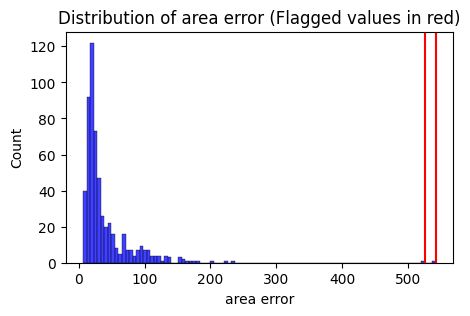

....................................................................................................


### FEW_NEIGHBORS

### Columns(s): radius error

**Issue&nbsp;ID**:&nbsp;5

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

...

**Number&nbsp;of&nbsp;exceptions**:&nbsp;1&nbsp;(0.1757%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,radius error,Closest smaller value,Closest larger value
9,0.297600,0.296300,0.297600
36,0.286000,0.286000,0.286000
66,0.235100,0.234500,0.235100
98,0.231500,0.231000,0.231500
106,0.306000,0.303700,0.306000
110,0.403000,0.400700,0.403000
175,0.220400,0.220400,0.220400
200,0.353400,0.351100,0.353400
232,0.223900,0.222200,0.223900
249,0.256200,0.256000,0.256200


**Flagged&nbsp;values**:

,radius error,Closest smaller value,Closest larger value
461,2.547000,1.509000,2.873000


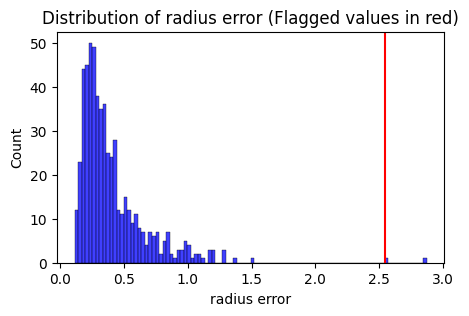

### Columns(s): perimeter error

**Issue&nbsp;ID**:&nbsp;6

A&nbsp;strong&nbsp;pattern,&nbsp;and&nbsp;exceptions&nbsp;to&nbsp;the&nbsp;pattern,&nbsp;were&nbsp;found.<br>

**Description**:&nbsp;The&nbsp;test&nbsp;marked&nbsp;any&nbsp;values&nbsp;more&nbsp;than&nbsp;2.122&nbsp;away&nbsp;from&nbsp;both&nbsp;the&nbsp;next&nbsp;smallest&nbsp;and&nbsp;next&nbsp;largest&nbsp;values<br>in&nbsp;the&nbsp;column.&nbsp;The&nbsp;minimum&nbsp;value&nbsp;for&nbsp;the&nbsp;column&nbsp;is&nbsp;0.757&nbsp;and&nbsp;the&nbsp;maximum&nbsp;is&nbsp;21.98.

**Number&nbsp;of&nbsp;exceptions**:&nbsp;1&nbsp;(0.1757%&nbsp;of&nbsp;rows)

**Examples&nbsp;of&nbsp;values&nbsp;NOT&nbsp;flagged**:

,perimeter error,Closest smaller value,Closest larger value
8,2.406000,2.397000,2.406000
34,2.183000,2.177000,2.183000
35,3.008000,3.002000,3.008000
54,2.097000,2.087000,2.097000
79,1.778000,1.778000,1.778000
96,2.410000,2.407000,2.410000
113,2.041000,2.039000,2.041000
137,1.143000,1.126000,1.143000
178,1.101000,1.094000,1.101000
208,1.491000,1.489000,1.491000


**Flagged&nbsp;values**:

,perimeter error,Closest smaller value,Closest larger value
461,18.650000,11.070000,21.980000


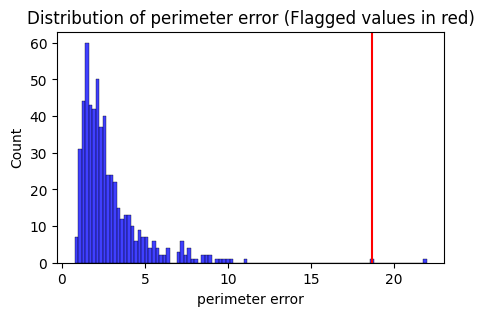

In [23]:
# Get more information about why row 461 was given a score of 3

dc.display_detailed_results(row_id_list=[461])